# ETA

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [78]:
df = pd.read_csv('../data/AEP_hourly.csv', index_col='Datetime', parse_dates=True)
df.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


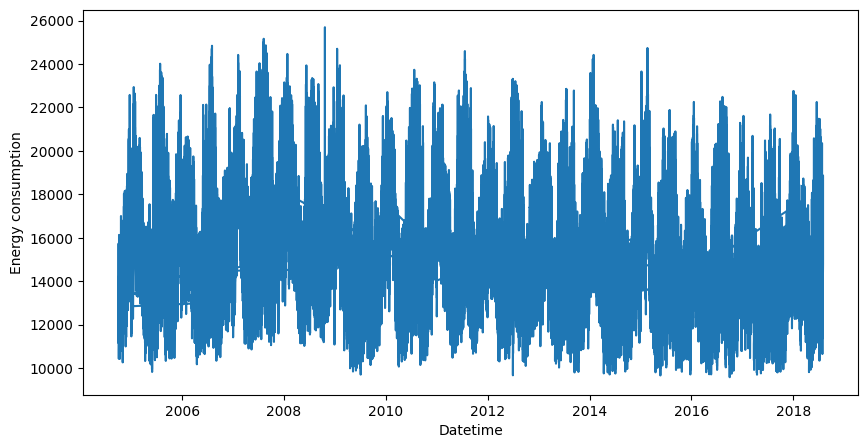

In [79]:
#Plot the dataset
plt.figure(figsize=(10,5))
plt.plot(df)
plt.xlabel('Datetime')
plt.ylabel('Energy consumption')
plt.show()

# PreProcessing

In [80]:
df = df.tz_localize(
    'US/Eastern',
    ambiguous='NaT',
    nonexistent='shift_forward'
)
print(df[df.index.isna()])
df = df[~df.index.isna()]
df = df.tz_convert('UTC')

           AEP_MW
Datetime         
NaT       11433.0
NaT       13348.0
NaT       13629.0
NaT       13590.0
NaT       12639.0
NaT       11871.0
NaT       14739.0
NaT       13506.0
NaT       12873.0
NaT       11478.0
NaT       13297.0
NaT       11087.0
NaT       11299.0
NaT       10936.0


In [81]:
df = df[~df.index.duplicated(keep='first')]
df = df.loc[df.index.max() - pd.Timedelta(days=180):]
print(len(df))
df.head(100)

794


,AEP_MW
Datetime,
2018-02-04 04:00:00+00:00,15959.0
2018-02-04 05:00:00+00:00,15362.0
2018-02-02 06:00:00+00:00,16025.0
2018-02-02 07:00:00+00:00,15876.0
2018-02-02 08:00:00+00:00,15995.0
...,...
2018-01-31 03:00:00+00:00,19086.0
2018-01-31 04:00:00+00:00,18426.0
2018-01-31 05:00:00+00:00,17873.0


In [82]:
df.isna().sum()

AEP_MW    0
dtype: int64

In [83]:
df = df.asfreq('h')
print(df.index.freq)

<Hour>


# Model

In [84]:
train, valid, test = np.split(df, [int(0.6*len(df)),int(0.8*len(df))])

/home/iprabhsidhu/EnergyPrediction/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [85]:
len(train)

489

In [86]:
params = {
    'non_seasonal': (1,0,2),
    'seasonal':(1,1,0,24),
}
Model = SARIMAX(train,order=params['non_seasonal'],seasonal_order=params['seasonal'])
Model = Model.fit(disp=False, method='powell')

print(Model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                              AEP_MW   No. Observations:                  489
Model:             SARIMAX(1, 0, 2)x(1, 1, [], 24)   Log Likelihood               -3341.182
Date:                             Thu, 12 Feb 2026   AIC                           6692.364
Time:                                     15:36:22   BIC                           6713.074
Sample:                                 01-01-2018   HQIC                          6700.515
                                      - 01-21-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8447      0.006    152.756      0.000       0.834       0.856
ma.L1          0.9063      

In [87]:
pred = Model.get_prediction(
    start=test.index[0],
    end=test.index[-1],
    dynamic=False
)
pred_mean = pred.predicted_mean
pred_mean = pred_mean.reindex(test.index)

In [88]:
pred_mean.index == test.index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [89]:
print(pred_mean.head())
print(test.head())

Datetime
2018-01-28 10:00:00+00:00    13420.164552
2018-01-28 11:00:00+00:00    13599.885483
2018-01-28 12:00:00+00:00    13920.371512
2018-01-28 13:00:00+00:00    14369.410701
2018-01-28 14:00:00+00:00    14747.801310
Freq: h, Name: predicted_mean, dtype: float64
                            AEP_MW
Datetime                          
2018-01-28 10:00:00+00:00  12392.0
2018-01-28 11:00:00+00:00  12626.0
2018-01-28 12:00:00+00:00  12980.0
2018-01-28 13:00:00+00:00  13508.0
2018-01-28 14:00:00+00:00  14067.0
